### orientational averaging

In [125]:
import macroscopics
import mtRspfuncs
import numpy as np
np.set_printoptions(linewidth=100000)

polarizations =  [[0.0, 0.0, 1.0], [0.0, 0.0, 1.0], [0.0, 0.0, 1.0], [0.0, 0.0, 1.0]]
num_fields = 4

# polarizations =  [[0.0, 0.0, 1.0], [0.0, 0.0, 1.0], [0.0, 0.0, 1.0]]
# num_fields = 3

pol_laser = macroscopics.get_pol_laser(polarizations)
pol_mat = macroscopics.get_iso_mat(num_fields)
pol_g = macroscopics.get_iso_f(num_fields)

# print(pol_laser)
# print(pol_mat)
allsum = np.array(pol_g, dtype='object')

new = []
for i in range(len(allsum)):
    new.append (allsum[i][0])

# for i in new:
#     print(i)

new = np.array(new)
# print(new)
# print('------------')
# print(new[:, 1])
# print(type(new), new.shape)
new = new.reshape(-1, 4)

print(new.shape)
print(new)

(27, 4)
[[0 0 0 0]
 [0 0 1 1]
 [0 0 2 2]
 [1 1 0 0]
 [1 1 1 1]
 [1 1 2 2]
 [2 2 0 0]
 [2 2 1 1]
 [2 2 2 2]
 [0 0 0 0]
 [0 1 0 1]
 [0 2 0 2]
 [1 0 1 0]
 [1 1 1 1]
 [1 2 1 2]
 [2 0 2 0]
 [2 1 2 1]
 [2 2 2 2]
 [0 0 0 0]
 [0 1 1 0]
 [0 2 2 0]
 [1 0 0 1]
 [1 1 1 1]
 [1 2 2 1]
 [2 0 0 2]
 [2 1 1 2]
 [2 2 2 2]]
------------------
[[0 0 0 0]
 [0 0 1 1]
 [0 0 2 2]
 [1 1 0 0]
 [1 1 1 1]
 [1 1 2 2]
 [2 2 0 0]
 [2 2 1 1]
 [2 2 2 2]
 [0 0 0 0]
 [0 1 0 1]
 [0 2 0 2]
 [1 0 1 0]
 [1 1 1 1]
 [1 2 1 2]
 [2 0 2 0]
 [2 1 2 1]
 [2 2 2 2]
 [0 0 0 0]
 [0 1 1 0]
 [0 2 2 0]
 [1 0 0 1]
 [1 1 1 1]
 [1 2 2 1]
 [2 0 0 2]
 [2 1 1 2]
 [2 2 2 2]]


In [126]:
def getting_abcgreek4avrg(num_f):
    
    import macroscopics
    pol_g = macroscopics.get_iso_f(num_fields)
    new = np.array([pol[0] for pol in pol_g], dtype='object').reshape(-1, num_f)
    
    return new

print('------------------')
print(getting_abcgreek4avrg(num_fields))

------------------
[[0 0 0 0]
 [0 0 1 1]
 [0 0 2 2]
 [1 1 0 0]
 [1 1 1 1]
 [1 1 2 2]
 [2 2 0 0]
 [2 2 1 1]
 [2 2 2 2]
 [0 0 0 0]
 [0 1 0 1]
 [0 2 0 2]
 [1 0 1 0]
 [1 1 1 1]
 [1 2 1 2]
 [2 0 2 0]
 [2 1 2 1]
 [2 2 2 2]
 [0 0 0 0]
 [0 1 1 0]
 [0 2 2 0]
 [1 0 0 1]
 [1 1 1 1]
 [1 2 2 1]
 [2 0 0 2]
 [2 1 1 2]
 [2 2 2 2]]


In [127]:
import openrsp_tensor_reader as orspReader

props_list, tens_list = orspReader.read_openrsp_tensor_file('./rsp_tensor')

for i in range(len(props_list)):
    props_list[i].addTensor(tens_list[i])
    # props_list[i].tellProp()

# mu_Q, mu_QQ, alpha_Q, alpha_QQ, F_abc
transf_props_list = []
for prop in props_list[:-1]:
    
    # cartesian basis to normal mode
    transf = orspReader.cart2normal(prop, './MOLECULE.INP', './rsp_tensor')
    transf_props_list.append(transf)
    
# len(transf_props_list)
# mu_Q.shape

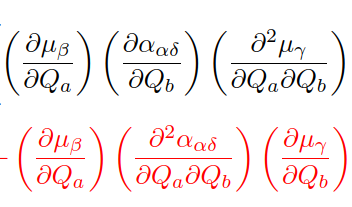

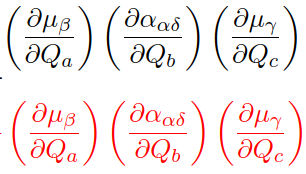

In [131]:
# formats = {'mu_Q': ('a',), 'alpha_Q': ('b',), 'mu_QQ': ('a', 'b',)}
# data = {'mu_Q': mu_Q, 'mu_QQ': mu_QQ, 'alpha_Q': alpha_Q, 'alpha_QQ': alpha_QQ, 'F_abc': F_abc}
# normalModes = (a, b, c,)
# gammaComps = (alpha, beta, gamma, delta,)

# returns gamma_(alpha, beta, gamma, delta) for one abc combination for given 'formats' definition
def avrg_abc(formula, data, normalModes, gammaCompsAll):
    
    avrg = 0.
    
    for gammaComps in gammaCompsAll:
        
        alpha, beta, gamma, delta = gammaComps
        abc = dict(zip(['a', 'b', 'c'], normalModes))
        abc_greek = {0: (beta,), 1: (alpha, delta,), 2: (gamma,)}

        tot = 1.

        for i, key in enumerate(formula):
            indx = tuple(abc[j] for j in formula[key]) + abc_greek[i]
            tot *= data[key][indx]
        avrg += tot
        
    return avrg/15

In [136]:
formats = {'mu_Q': ('a',), 'alpha_Q': ('b',), 'mu_QQ': ('a', 'b',)}

a, b, c = 0, 0, 1
abc = {'a': a, 'b': b, 'c': c}

mu_Q, mu_QQ, alpha_Q, alpha_QQ, F_abc = transf_props_list
data = {'mu_Q': mu_Q, 'mu_QQ': mu_QQ, 'alpha_Q': alpha_Q, 'alpha_QQ': alpha_QQ, 'F_abc': F_abc}

gammaCompsAll = getting_abcgreek4avrg(num_f=4)
avrg_abc(formats, data, [a, b, c], gammaCompsAll)

3.513623930888385e-10

3.513623930888385e-10

In [ ]:
# for (a, b)
a, b = 0, 0

# gamma_arvg_ab = 
tot = 0.

for term in new:
    alpha, beta, gamma, delta = term
    tot += mu_Q[a, beta]*alpha_Q[b, alpha, delta]*mu_QQ[a, b, gamma]

tot = tot/15
print(tot)

In [75]:
p = np.array([['Saa*S_bb'], ['Sab*S_ab'], ['Sab*S_ba']], dtype=object)
p = np.array([2, 3, 4], dtype=object)

m = np.array([[4, -1, -1], [-1, 4, -1], [-1, -1, 4]], dtype=object)/30
Af = np.array([1, 1, 1]).T

xx = np.inner(Af, m)
print(xxx)
xxx = np.inner(xx, p)
print(xxx)

q = np.outer(m, p)
# print(q)

18
0.6000000000000001


In [62]:
z = np.array([0., 0., 1.])
np.outer(z, z)

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 1.]])

In [67]:
zz = np.einsum('i,j', z, z)
zzzz = np.einsum('ij,kl', zz, zz)
print(zzzz.shape)
zzzz[(0, 1, 0, 0)] = 9.
print(zzzz[(0, 1, 0, 0)])
zzzz

(3, 3, 3, 3)
9.0


array([[[[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[9., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]]],


       [[[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]]],


       [[[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 1.]]]])

In [ ]:
zz = np.outer(z, z)
zzz = np.outer(zz, z)
zzzz = np.outer(zzz, z)

print(zz)
# print(zzz)
print(zzzz)

[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 1.]]
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 1.]]


In [26]:
x = np.array(['a', 'b', 'c'], dtype=object)
np.outer(x, [1, 2, 3])

array([['a', 'aa', 'aaa'],
       ['b', 'bb', 'bbb'],
       ['c', 'cc', 'ccc']], dtype=object)

In [28]:
a = np.arange(25).reshape(5,5)
b = np.arange(5)
c = np.arange(6).reshape(2,3)

In [30]:
np.einsum('ii', a)
np.trace(a)

60

In [32]:
print(a)
print(b)

np.einsum('i,j', np.arange(2)+1, b)

[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]
 [20 21 22 23 24]]
[0 1 2 3 4]


array([[0, 1, 2, 3, 4],
       [0, 2, 4, 6, 8]])